In [144]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, precision_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

In [145]:
df = pd.read_csv("novagen_dataset.csv")

In [146]:
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  Phys

Age                      0
BMI                      0
Blood_Pressure           0
Cholesterol              0
Glucose_Level            0
Heart_Rate               0
Sleep_Hours              0
Exercise_Hours           0
Water_Intake             0
Stress_Level             0
Target                   0
Smoking                  0
Alcohol                  0
Diet                     0
MentalHealth             0
PhysicalActivity         0
MedicalHistory           0
Allergies                0
Diet_Type__Vegan         0
Diet_Type__Vegetarian    0
Blood_Group_AB           0
Blood_Group_B            0
Blood_Group_O            0
dtype: int64

# Data Preprcoessing

In [147]:
#Data Preprocessing
cols = ["Diet_Type__Vegan", "Diet_Type__Vegetarian", "Blood_Group_AB", "Blood_Group_B", "Blood_Group_O"]
df[cols] = df[cols].astype(int)

num_cols = df.select_dtypes(include = ["number"])

In [148]:
df[cols].dtypes

Diet_Type__Vegan         int64
Diet_Type__Vegetarian    int64
Blood_Group_AB           int64
Blood_Group_B            int64
Blood_Group_O            int64
dtype: object

# EDA - Exploratory Data Analysis

Text(0, 0.5, 'Count')

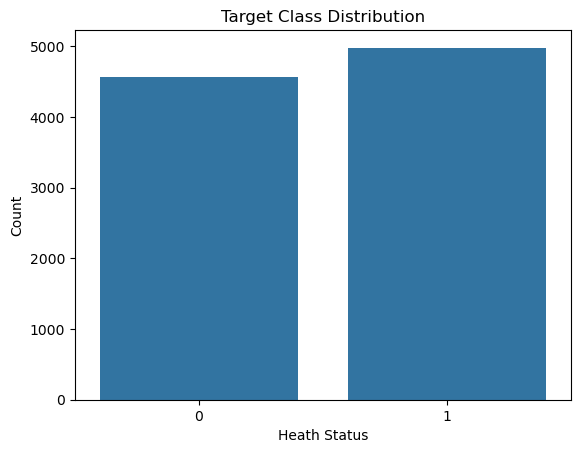

In [149]:
#Check Class_Balance

sns.countplot(
    data = df,
    x = "Target"
)
plt.title("Target Class Distribution")
plt.xlabel("Heath Status")
plt.ylabel("Count")

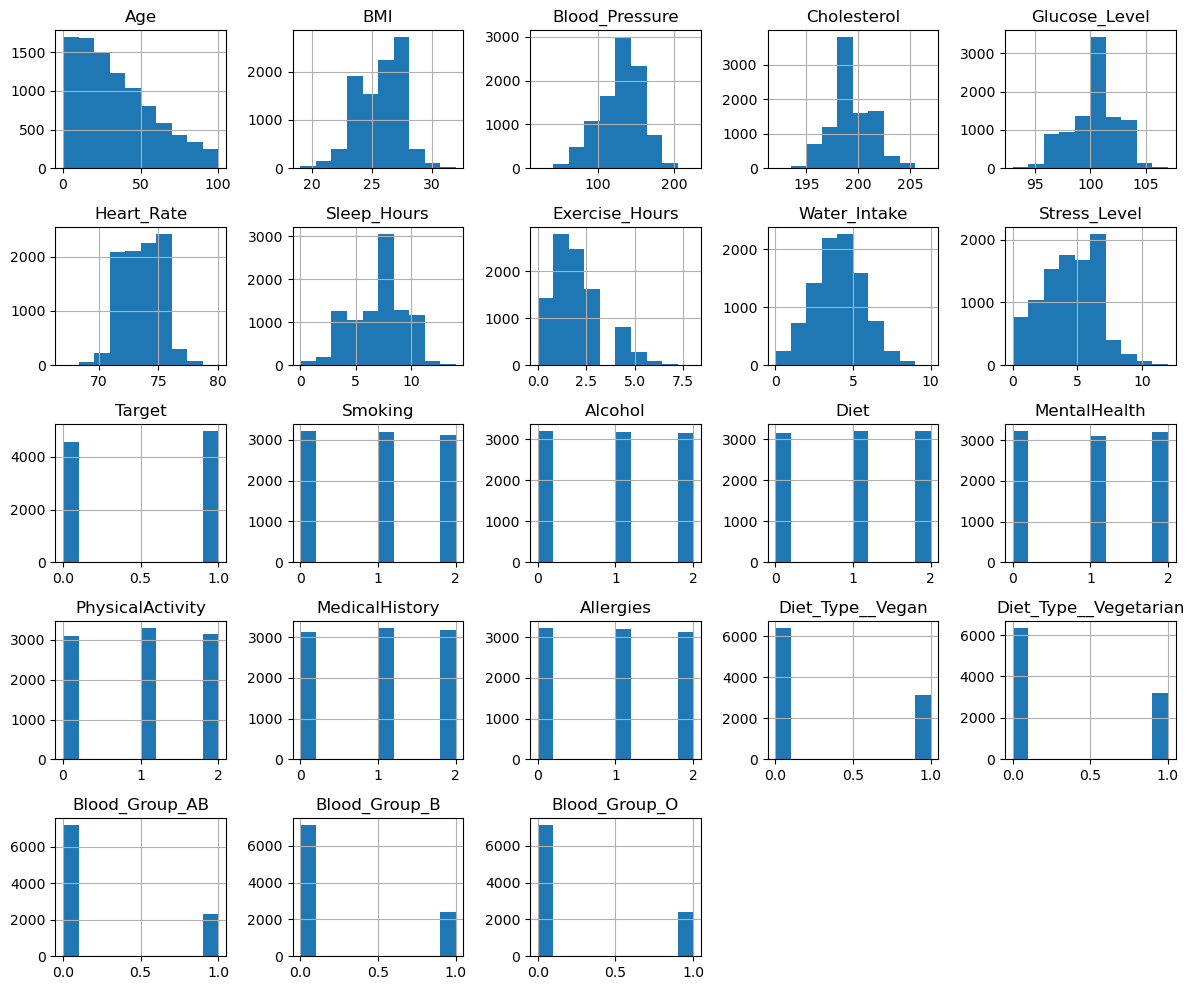

In [150]:
# Histogram Feature Distribution

df.hist(figsize = (12, 10))
plt.tight_layout()

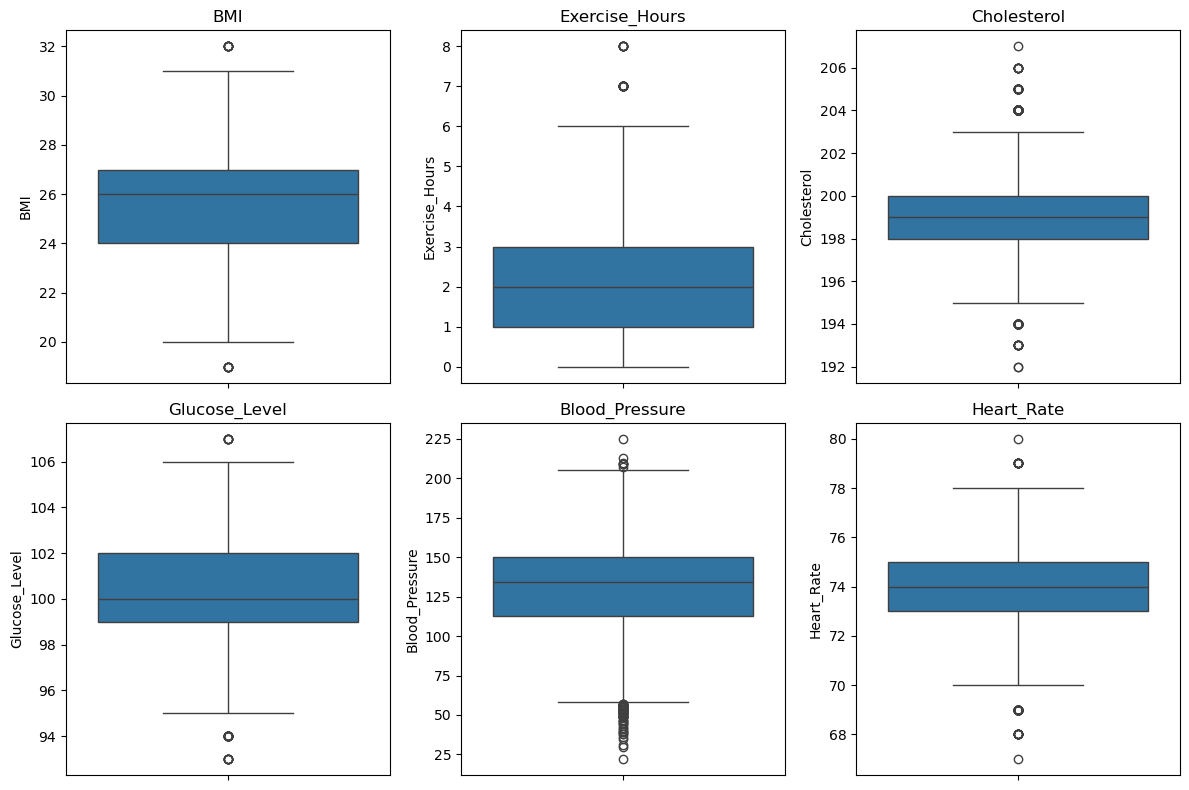

In [151]:
features = ["BMI", "Exercise_Hours", "Cholesterol","Glucose_Level","Blood_Pressure","Heart_Rate"]

plt.figure(figsize=(12,8))

for i, col in enumerate(features,1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

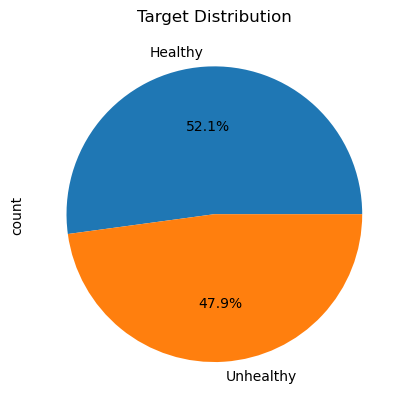

In [152]:
#Pie Chart for Healthy and Unhealthy Distribution

df["Target"].value_counts().plot(
    kind = "pie",
    autopct = "%1.1f%%",
    labels = ["Healthy", "Unhealthy"]
)
plt.title("Target Distribution")
plt.show()

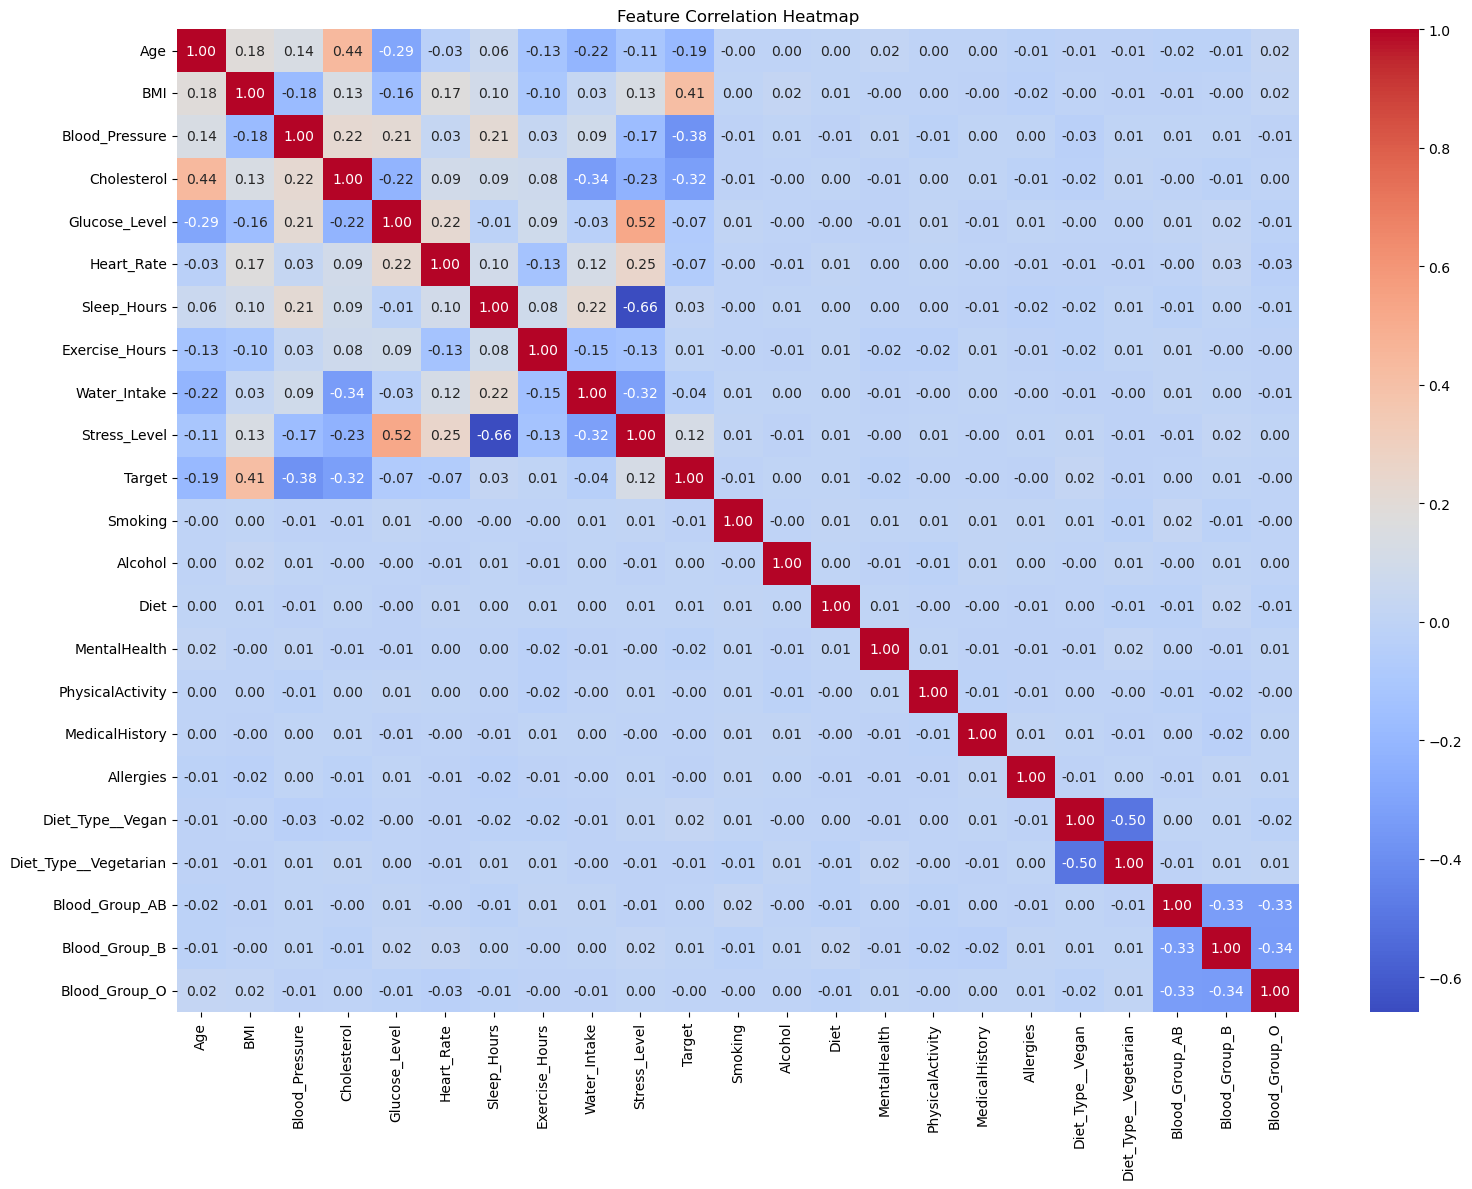

In [153]:
#Heatmap

corr = df.corr()

plt.figure(figsize = (16, 12))

sns.heatmap(
    corr,
    annot = True,
    cmap = "coolwarm",
    fmt = ".2f"
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [154]:
X = df.drop("Target", axis=1)
y = df["Target"]

In [155]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify=y
)

# Data Scaling

In [156]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression

In [157]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [158]:
y_test_pred = lr.predict(X_test_scaled)
y_train_pred = lr.predict(X_train_scaled)

In [159]:
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Test Accuracy: 0.8136125654450261
Train Accuracy: 0.8175153815944496
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.80      0.80       914
           1       0.82      0.83      0.82       996

    accuracy                           0.81      1910
   macro avg       0.81      0.81      0.81      1910
weighted avg       0.81      0.81      0.81      1910



# Support Vector Classifier

In [160]:
svc = SVC(probability=True)
svc.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [161]:
y_test_pred = svc.predict(X_test_scaled)
y_train_pred = svc.predict(X_train_scaled)

In [162]:
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Test Accuracy: 0.9465968586387434
Train Accuracy: 0.9553606492996466
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.93      0.94       914
           1       0.93      0.96      0.95       996

    accuracy                           0.95      1910
   macro avg       0.95      0.95      0.95      1910
weighted avg       0.95      0.95      0.95      1910



# Decision Tree Classifier

In [163]:
dtc = DecisionTreeClassifier(max_depth = 3)
dtc.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [164]:
y_test_pred = dtc.predict(X_test)
y_train_pred = dtc.predict(X_train)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))

print("Classification Report:\n", classification_report(y_test, y_test_pred))

Test Accuracy: 0.7952879581151833
Train Accuracy: 0.8146354234847493
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.69      0.76       914
           1       0.76      0.89      0.82       996

    accuracy                           0.80      1910
   macro avg       0.81      0.79      0.79      1910
weighted avg       0.80      0.80      0.79      1910



# Pre_pruning in Decision Tree Classifier

In [165]:
#For Depth
best_acc = 0
best_depth = None

for depth in max_depth:
    model = DecisionTreeClassifier(max_depth = depth, random_state = 42)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f"for depth = {depth}, accuracy = {acc}")
    if acc > best_acc:
        best_acc = acc
        best_depth = depth

print(f"Best depth = {best_depth}, Best accuracy = {best_acc}")     

for depth = 2, accuracy = 0.7759162303664922
for depth = 3, accuracy = 0.7952879581151833
for depth = 4, accuracy = 0.8272251308900523
for depth = 5, accuracy = 0.8539267015706806
for depth = 6, accuracy = 0.8596858638743455
for depth = 7, accuracy = 0.8764397905759163
for depth = 8, accuracy = 0.8821989528795812
for depth = 9, accuracy = 0.8863874345549738
for depth = 10, accuracy = 0.8890052356020942
for depth = 15, accuracy = 0.8910994764397906
for depth = 17, accuracy = 0.8910994764397906
for depth = 20, accuracy = 0.8931937172774869
Best depth = 20, Best accuracy = 0.8931937172774869


In [166]:
# For minimum no of Splits
best_acc = 0
best_sample_split = None

for split in min_samples_split:
    model = DecisionTreeClassifier(max_depth = best_depth, min_samples_split = split, random_state = 42)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f"for sample split = {split}, accuracy = {acc}")  
    if acc > best_acc :
        best_acc = acc
        best_sample_split = split

print(f"Best Sample Split = {best_sample_split}, Best accuracy = {best_acc}")          

for sample split = 5, accuracy = 0.8952879581151832
for sample split = 10, accuracy = 0.8921465968586387
for sample split = 15, accuracy = 0.8926701570680629
for sample split = 20, accuracy = 0.8994764397905759
for sample split = 25, accuracy = 0.9026178010471204
for sample split = 30, accuracy = 0.9068062827225131
for sample split = 35, accuracy = 0.9031413612565445
for sample split = 40, accuracy = 0.9020942408376963
Best Sample Split = 30, Best accuracy = 0.9068062827225131


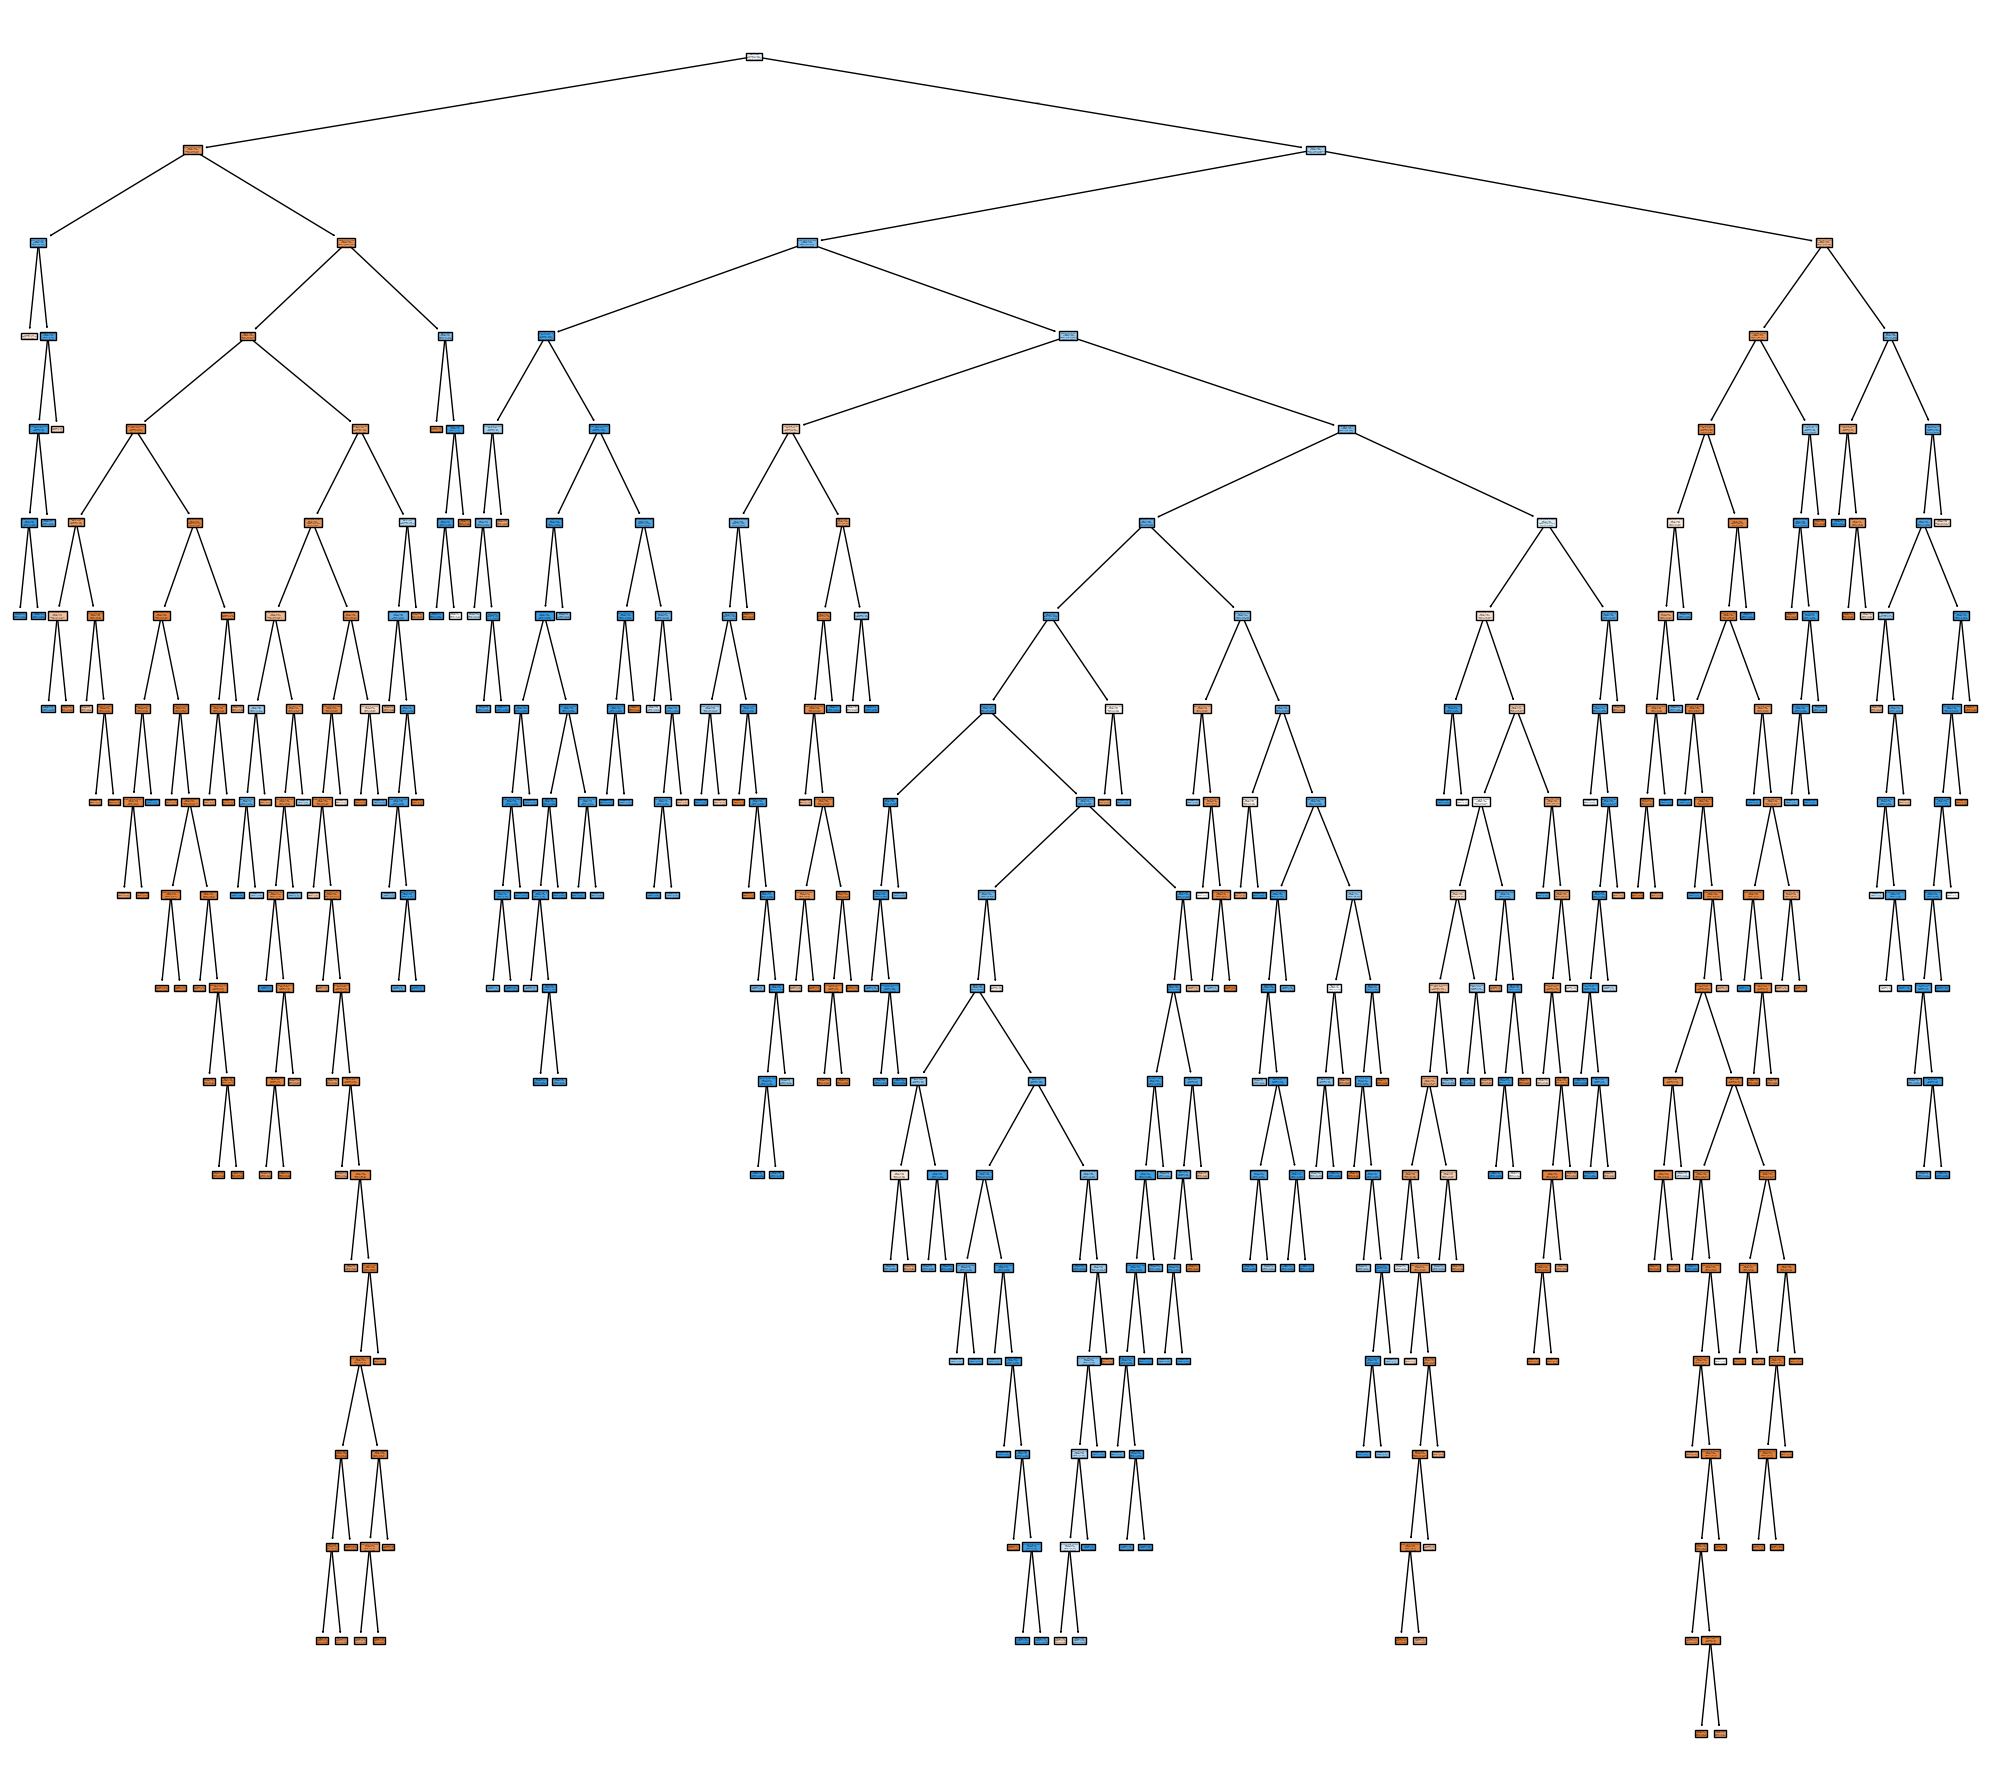

In [167]:
plt.figure(figsize = (20, 18))
plot_tree(
   model,
   feature_names = X.columns,
   class_names = ["Healthy", "Unhealthy"],
   filled = True
)
plt.tight_layout()
plt.show()

# Post_Pruning in Decision Tree Classifier

In [168]:
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

In [169]:
best_acc = 0
best_alpha = None

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    
    if acc > best_acc:
        best_acc = acc
        best_alpha = alpha

print("Best ccp_alpha:", best_alpha)
print("Best accuracy:", best_acc)

Best ccp_alpha: 0.00027998697824891945
Best accuracy: 0.912565445026178


In [170]:
post_pruned_tree = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=best_alpha
)

post_pruned_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [171]:
y_test_pred = post_pruned_tree.predict(X_test)
y_train_pred = post_pruned_tree.predict(X_train)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Test Accuracy: 0.912565445026178
Train Accuracy: 0.961120565519047
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.89      0.91       914
           1       0.90      0.93      0.92       996

    accuracy                           0.91      1910
   macro avg       0.91      0.91      0.91      1910
weighted avg       0.91      0.91      0.91      1910



# GridSearchCV

In [172]:
from sklearn.model_selection import GridSearchCV

#Define Param Grid

param_grid = {
    "max_depth": [5, 10, 15, 20, 25],
    "min_samples_split": [5, 10, 20, 30, 40],
    "min_samples_leaf": [1, 3, 5],
    "criterion":["gini", "entropy"]
}

In [173]:
dt_clf = DecisionTreeClassifier(random_state = 42)

grid = GridSearchCV(
    estimator = dt_clf,
    param_grid = param_grid,
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1
)

grid.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 3, ...], 'min_samples_split': [5, 10, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [174]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best CV Score: 0.8952735576379102


In [175]:
best_tree = grid.best_estimator_

In [176]:
y_pred = best_tree.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9
              precision    recall  f1-score   support

           0       0.91      0.88      0.89       914
           1       0.89      0.92      0.91       996

    accuracy                           0.90      1910
   macro avg       0.90      0.90      0.90      1910
weighted avg       0.90      0.90      0.90      1910



# Bagging

In [177]:
bag = BaggingClassifier(
    n_estimators = 100,
    random_state = 42,
)

bag.fit(X_train, y_train)

y_pred = bag.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9424083769633508
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       914
           1       0.93      0.96      0.95       996

    accuracy                           0.94      1910
   macro avg       0.94      0.94      0.94      1910
weighted avg       0.94      0.94      0.94      1910



# AdaBoost Classifier

In [178]:
boost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=42
)

boost.fit(X_train, y_train)

y_pred = boost.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8361256544502618
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       914
           1       0.84      0.84      0.84       996

    accuracy                           0.84      1910
   macro avg       0.84      0.84      0.84      1910
weighted avg       0.84      0.84      0.84      1910



# Gradient Boosting

In [179]:
gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.9198952879581151


# Still SVC is Having the Highest Accuracy overall

# Confusion Matrix

<Figure size 600x500 with 0 Axes>

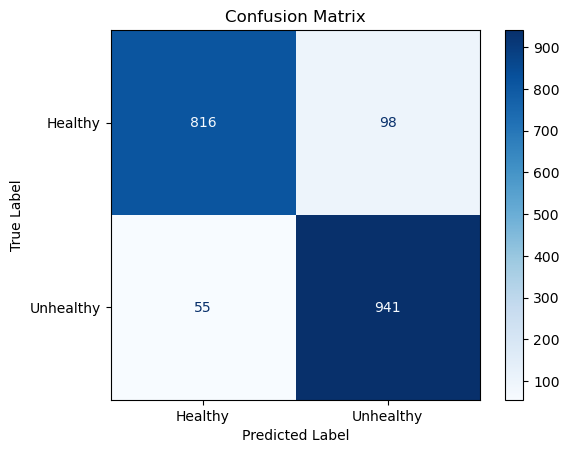

In [180]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy", "Unhealthy"]
)

plt.figure(figsize=(6,5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ROC Curve

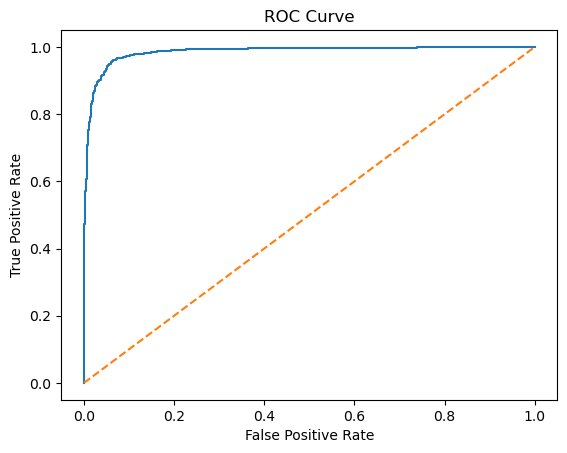

In [181]:
y_prob = svc.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [182]:
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.985125403144306


# Model Comparison Visualization

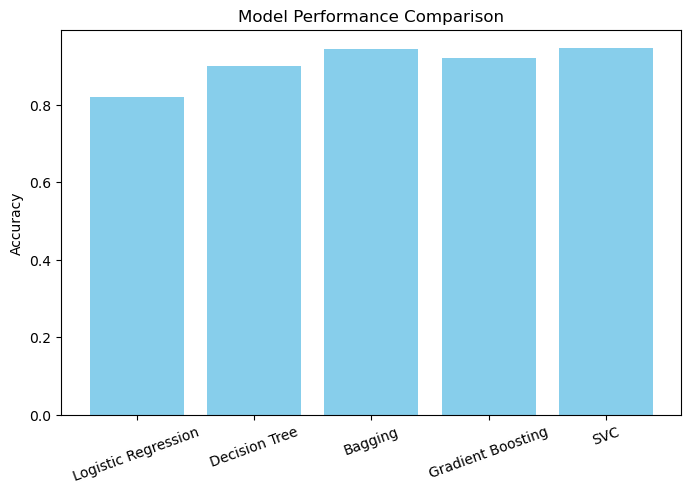

In [183]:
models = ["Logistic Regression", "Decision Tree", "Bagging", "Gradient Boosting", "SVC"]
scores = [0.82, 0.90, 0.942, 0.919, 0.946]

plt.figure(figsize=(8,5))
plt.bar(models, scores, color="skyblue")
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")
plt.xticks(rotation=20)
plt.show()

# Feature Importance

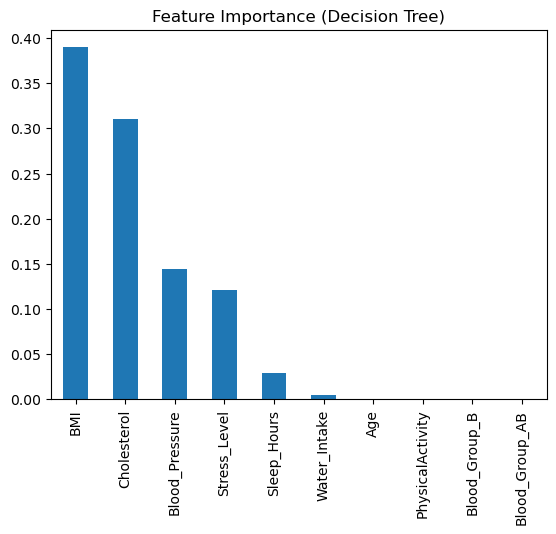

In [184]:
importance = dtc.feature_importances_

feat_imp = pd.Series(importance, index=X.columns)

feat_imp.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Feature Importance (Decision Tree)")
plt.show()

# Save the Final Model

In [185]:
import joblib

joblib.dump(svc, "health_prediction_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

# Simple Prediction Function

In [192]:
def predict_health(data):
    
    data_df = pd.DataFrame([data], columns=X.columns)

    data_scaled = scaler.transform(data_df)

    prediction = svc.predict(data_scaled)[0]

    if prediction == 0:
        return "Healthy"
    else:
        return "Unhealthy"

In [193]:
sample = X_test.iloc[10]

predict_health(sample)

'Healthy'

## Conclusion

In this project, multiple supervised machine learning models were developed to predict health status based on lifestyle and medical indicators.

The workflow included data preprocessing, exploratory data analysis (EDA), feature scaling using RobustScaler, and training several classification models including Logistic Regression, Decision Tree, Bagging, AdaBoost, Gradient Boosting, and Support Vector Classifier (SVC).

After model evaluation and comparison, the Support Vector Classifier achieved the highest performance with a test accuracy of **94.66%**, making it the best-performing model for this dataset.

Further evaluation using a confusion matrix and ROC curve confirmed that the model generalizes well and makes reliable predictions.

Finally, the trained model and scaler were saved using Joblib, and a prediction function was implemented to make the model reusable for new data.

This project demonstrates a complete machine learning workflow from data exploration to model deployment preparation.